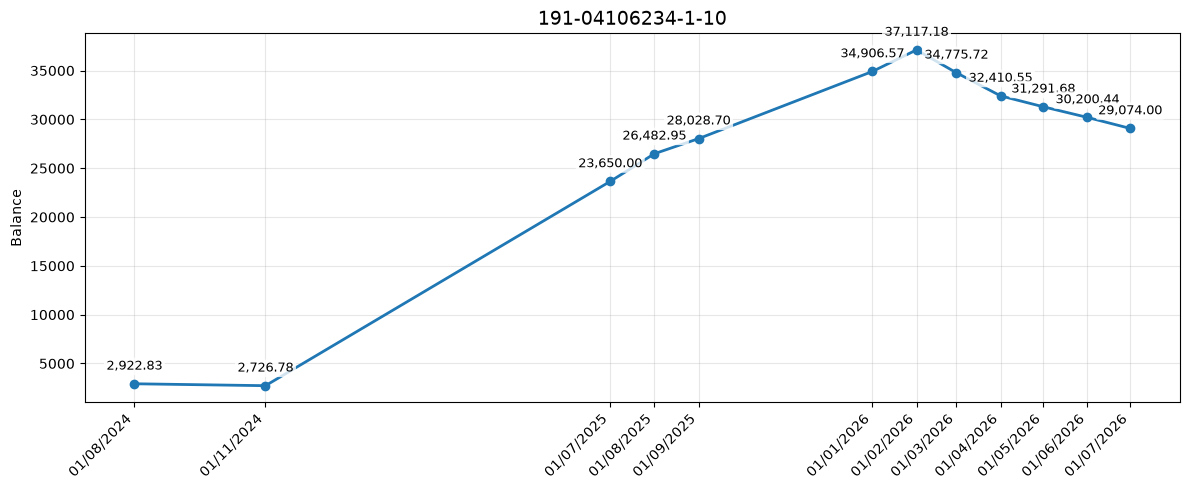

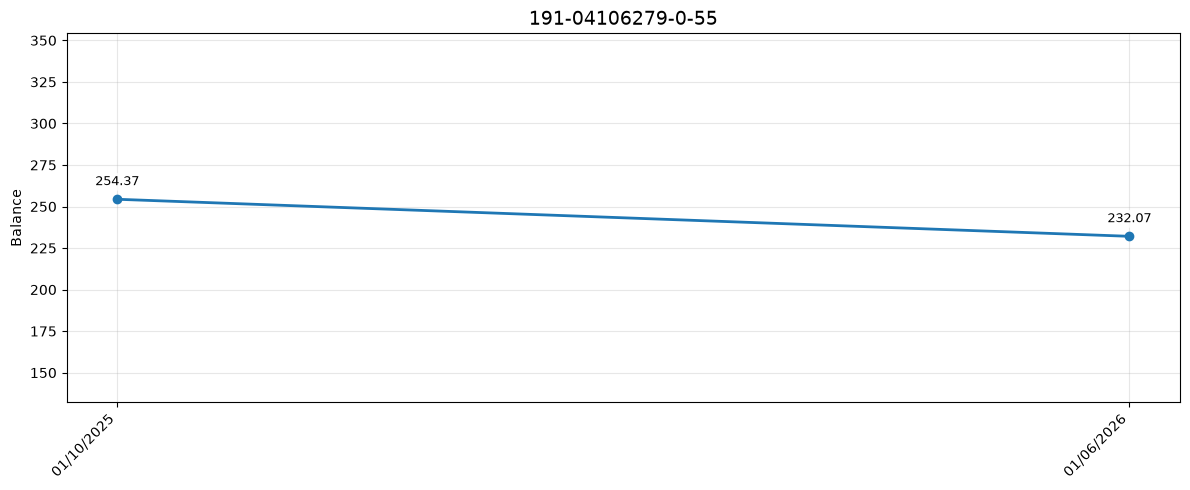

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "http://new-service:8000"


# Fetch all documents
docs_response = requests.get(f"{BASE_URL}/documents/", params={"limit": 1000})
docs_response.raise_for_status()
documents = docs_response.json().get("documents", [])



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

docs_df = pd.DataFrame(documents)

required_columns = {"registration_date", "balance", "account"}

if not docs_df.empty and required_columns.issubset(docs_df.columns):

    docs_df["registration_date"] = pd.to_datetime(
        docs_df["registration_date"],
        errors="coerce",
    )

    docs_df["balance"] = pd.to_numeric(
        docs_df["balance"],
        errors="coerce",
    )

    docs_df["balance"] = docs_df["balance"].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    docs_df = docs_df.dropna(
        subset=["registration_date", "balance", "account"],
    )

    if docs_df.empty:
        print("No hay datos válidos para graficar.")

    else:
        for account, group in docs_df.groupby("account"):

            group = (
                group.sort_values("registration_date")
                .copy()
                .reset_index(drop=True)
            )

            ymin = group["balance"].min()
            ymax = group["balance"].max()

            if not np.isfinite(ymin) or not np.isfinite(ymax):
                print(f"Se omitió la cuenta {account}: límites inválidos.")
                continue

            balance_range = ymax - ymin
            margin = max(abs(balance_range) * 0.05, 100)

            fig, ax = plt.subplots(figsize=(12, 5))

            ax.plot(
                group["registration_date"],
                group["balance"],
                marker="o",
                linewidth=2,
            )

            # Mostrar una fecha por cada punto
            ax.set_xticks(group["registration_date"])
            ax.set_xticklabels(
                group["registration_date"].dt.strftime("%d/%m/%Y"),
                rotation=45,
                ha="right",
            )

            # Mostrar el balance encima de cada punto
            for x, y in zip(group["registration_date"], group["balance"]):
                ax.annotate(
                    f"{y:,.2f}",
                    xy=(x, y),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    bbox=dict(
                        boxstyle="round,pad=0.2",
                        facecolor="white",
                        edgecolor="none",
                        alpha=0.8,
                    ),
                )

            ax.set_title(str(account), fontsize=14)
            ax.set_xlabel("")
            ax.set_ylabel("Balance")

            ax.set_ylim(
                ymin - margin,
                ymax + margin,
            )

            ax.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()
            plt.close(fig)

else:
    if docs_df.empty:
        print("El DataFrame está vacío.")
    else:
        missing_columns = required_columns.difference(docs_df.columns)
        print(f"Faltan columnas requeridas: {missing_columns}")